## Social Network Analysis and Influence Detection
### Problem Statement
In social networks,identifying influential users is crucial for marketing,recommendation systems,and  information spread

This project analyzes network structure and identifies key influential nodes using graph based metrics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import random

In [2]:
df = pd.read_csv("artist_edges.csv")
print(df.head())
print(df.columns)

   node_1  node_2
0       0    1794
1       0    3102
2       0   16645
3       0   23490
4       0   42128
Index(['node_1', 'node_2'], dtype='object')


## Network Overview
The network represents users as nodes and connections between them as edges.

In [3]:
# create network

In [4]:
G = nx.from_pandas_edgelist(df, source='node_1', target='node_2')

print("Node Number:", G.number_of_nodes())
print("Edge Number:", G.number_of_edges())

Node Number: 50515
Edge Number: 819306


In [5]:
# basic analysis
print("Is Connected ?", nx.is_connected(G))
print("Component number:", nx.number_connected_components(G))

Is Connected ? True
Component number: 1


## Centrality Measures

Degree Centrality: measures how connected a node is

Betweenness Centrality: identifies nodes that act as bridges

PageRank: measures influence based on network structure

Eigenvector Centrality: identifies nodes connected to important nodes

## Degree Distribution

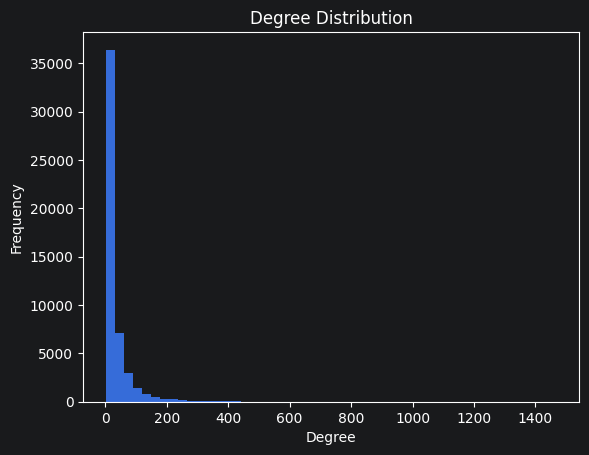

In [6]:
degrees = [d for n, d in G.degree()]

plt.hist(degrees, bins=50)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

## PageRank Analysis

In [9]:
pr = nx.pagerank(G)

top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top PageRank Nodes:")
print(top_pr)

Top PageRank Nodes:
[(48099, 0.0008395299511401834), (41998, 0.0008290134946126335), (7675, 0.000823344800767568), (9187, 0.0007867797937298447), (46117, 0.0007486419060054939), (37078, 0.0007078547181054743), (13455, 0.0006964354904197494), (37439, 0.0006787822236480251), (6970, 0.0006773126606591094), (31746, 0.0006703475663419558)]


## Betweenness Centrality

In [7]:
sample_nodes = random.sample(list(G.nodes()), 2000)
G_sample = G.subgraph(sample_nodes)

bet_cent = nx.betweenness_centrality(G_sample)

top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top Betweenness Nodes:")
print(top_bet)

Top Betweenness Nodes:
[(2568, 0.03010282013803701), (39019, 0.02821376998225783), (28539, 0.018355232653336512), (31363, 0.01644601309391644), (2000, 0.015381975676406071), (26836, 0.015119444764286321), (8146, 0.014388484728476984), (1740, 0.012164893071367035), (38626, 0.011916151671791568), (50083, 0.010428566381628668)]


## Eigen Vector

In [8]:
eig_cent = nx.eigenvector_centrality(G_sample, max_iter=1000)

top_eig = sorted(eig_cent.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top Eigenvector Nodes:")
print(top_eig)

Top Eigenvector Nodes:
[(17590, 0.28855209202812676), (26836, 0.27432389526223966), (28539, 0.2726422480999416), (31363, 0.2714210028357691), (39019, 0.23875016089565115), (2568, 0.19174290098404156), (50083, 0.1592346623836103), (1132, 0.15547818774352942), (8146, 0.15458118626875736), (914, 0.15370662960816595)]


## Top Influencers
The top 10 nodes with the highest PageRank scores were selected as the most influential users in the network.

These nodes are considered influential because they are centrally positioned in the network and connected to other important nodes.

In [10]:
top_nodes = sorted(pr.items(), key=lambda x: x[1], reverse=True)
top_nodes[:10]

[(48099, 0.0008395299511401834),
 (41998, 0.0008290134946126335),
 (7675, 0.000823344800767568),
 (9187, 0.0007867797937298447),
 (46117, 0.0007486419060054939),
 (37078, 0.0007078547181054743),
 (13455, 0.0006964354904197494),
 (37439, 0.0006787822236480251),
 (6970, 0.0006773126606591094),
 (31746, 0.0006703475663419558)]

In [11]:
top_df = pd.DataFrame(top_nodes[:10], columns=["Node", "Pagerank Score"])
top_df

,Node,Pagerank Score
0,48099,0.000840
1,41998,0.000829
2,7675,0.000823
3,9187,0.000787
4,46117,0.000749
5,37078,0.000708
6,13455,0.000696
7,37439,0.000679
8,6970,0.000677
9,31746,0.000670


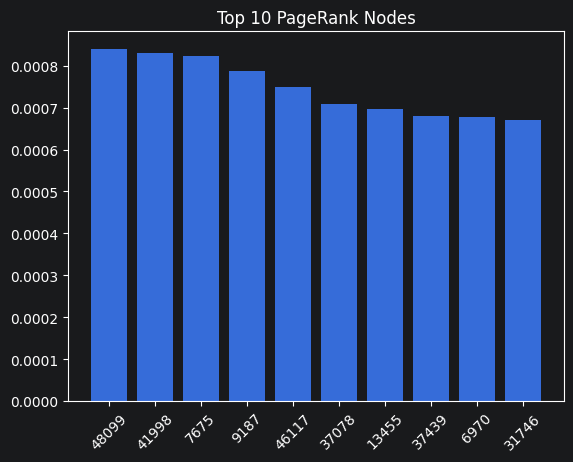

In [12]:
plt.bar(top_df["Node"].astype(str), top_df["Pagerank Score"])
plt.xticks(rotation=45)
plt.title("Top 10 PageRank Nodes")
plt.show()

## Key Findings

PageRank helped identify the most influential nodes in the network.

These nodes are important because they are connected to other important nodes.

The network shows variation in connectivity among users.

## Conclusion

This project analyzed the structure of a social network using graph-based methods.

Centrality measures such as PageRank were used to identify the most influential nodes in the network.

These nodes play a key role in connectivity and information flow.

This type of analysis can be useful in applications such as marketing, recommendation systems, and social media analysis.